In [1]:
import pandas as pd
import re
import io

# 1. Read the file content
with open("dataSet_9.txt", "r", encoding="utf-8") as f:
    content = f.read()

clean_content = content
# clean_content = re.sub(r'\', '', content)

# 3. Find the start of the data table (after the header N v1 v2)
# We look for the first occurrence of "1" followed by the values
data_start_match = re.search(r'\n1\s+', clean_content)
if data_start_match:
    data_body = clean_content[data_start_match.start():]
else:
    # Fallback if the pattern is slightly different
    data_body = clean_content

# 4. Load into Pandas
# sep='\s+' handles any number of spaces as a delimiter
df = pd.read_csv(io.StringIO(data_body), sep='\s+', names=['N', 'v1', 'v2'], index_col='N')

# Display first few rows to check
print("Data loaded successfully:")
print(df.head())


<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Qweyke\AppData\Local\Temp\ipykernel_796\3378509640.py:23: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(io.StringIO(data_body), sep='\s+', names=['N', 'v1', 'v2'], index_col='N')


Data loaded successfully:
          v1         v2
N                      
1  -9.560760  -8.426468
2 -10.425912  -9.429099
3 -11.905084 -12.327247
4  -8.418010 -12.787565
5  -9.231816 -11.358239


Hypothesis confirmed: populations are the same (p >= 0.10)
Accept H0: Mean is -10 (p-value: 0.6833 >= 0.01)


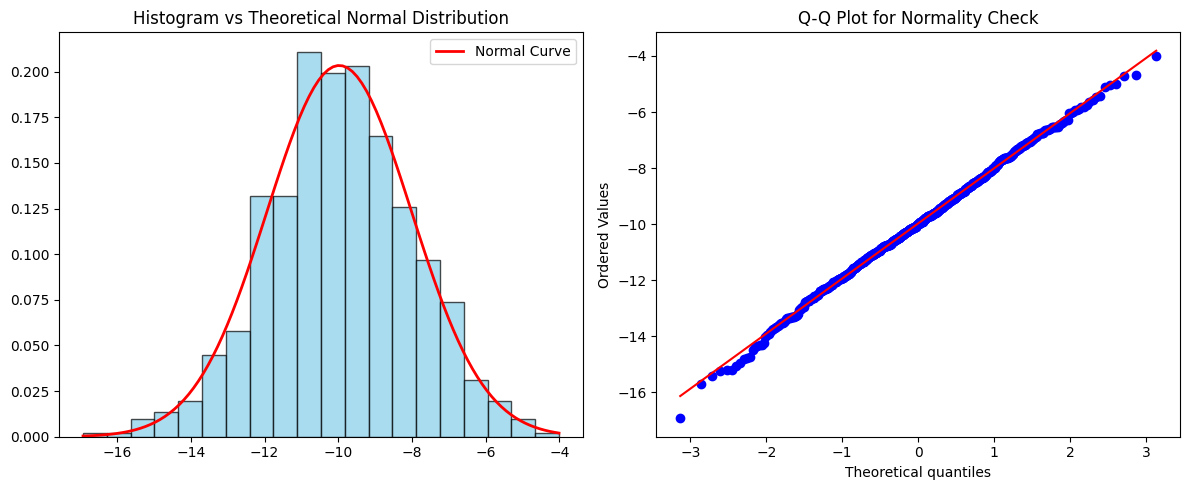

Task 2 (Mean=-10) p-value: 0.6833
Task 3 (Normality Chi2) p-value: 0.9673


In [10]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import re

# Define significance levels
alpha_comparison = 0.10  # 10% significance level for point 1
alpha_mean_test = 0.01  # 1% significance level for point 2 (99% confidence)

v1 = df["v1"].dropna()
v2 = df["v2"].dropna()

# 1. Check variances (F-test)
f_stat = v1.var() / v2.var()
# Calculate two-sided p-value for F-test
p_val_f = 2 * min(
    stats.f.cdf(f_stat, len(v1) - 1, len(v2) - 1),
    1 - stats.f.cdf(f_stat, len(v1) - 1, len(v2) - 1),
)

# 2. Check means (T-test)
t_stat, p_val_t = stats.ttest_ind(v1, v2)

# Decision logic for Task 1
# Both p-values must be greater than alpha to confirm the populations are the same
if p_val_f >= alpha_comparison and p_val_t >= alpha_comparison:
    print("Hypothesis confirmed: populations are the same (p >= 0.10)")
    combined = pd.concat([v1, v2])
else:
    print("Hypothesis rejected: populations are different (p < 0.10)")
    combined = v1

# 3. Point 2: T-test for mu = -10 (99% confidence means alpha = 0.01)
t_stat_10, p_val_10 = stats.ttest_1samp(combined, -10)

if p_val_10 < alpha_mean_test:
    print(f"Reject H0: Mean is NOT -10 (p-value: {p_val_10:.4f} < 0.01)")
else:
    print(f"Accept H0: Mean is -10 (p-value: {p_val_10:.4f} >= 0.01)")


final_sample = combined

mu, std = final_sample.mean(), final_sample.std()
observed_freq, bin_edges = np.histogram(final_sample, bins=10)
n = len(final_sample)
expected_freq = []

# Calculate expected frequencies adjusted for normal distribution range
for i in range(len(bin_edges) - 1):
    low, high = bin_edges[i], bin_edges[i + 1]
    if i == 0:
        p = stats.norm.cdf(high, mu, std)  # First bin: -inf to high
    elif i == len(bin_edges) - 2:
        p = 1 - stats.norm.cdf(low, mu, std)  # Last bin: low to +inf
    else:
        p = stats.norm.cdf(high, mu, std) - stats.norm.cdf(low, mu, std)
    expected_freq.append(p * n)

# Run Chi-Square goodness-of-fit test
chi_stat, p_val_chi = stats.chisquare(observed_freq, f_exp=expected_freq)

# --- 5. VISUALIZATION ---
plt.figure(figsize=(12, 5))

# Plot Histogram and Theoretical Normal PDF
plt.subplot(1, 2, 1)
plt.hist(
    final_sample, bins=20, density=True, color="skyblue", edgecolor="black", alpha=0.7
)
x_axis = np.linspace(final_sample.min(), final_sample.max(), 100)
plt.plot(x_axis, stats.norm.pdf(x_axis, mu, std), "r-", lw=2, label="Normal Curve")
plt.title("Histogram vs Theoretical Normal Distribution")
plt.legend()

# Plot Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(final_sample, dist="norm", plot=plt)
plt.title("Q-Q Plot for Normality Check")

plt.tight_layout()
plt.savefig("analysis_results.png")  # Saving plot for the report
plt.show()

# Final results output
print(f"Task 2 (Mean=-10) p-value: {p_val_10:.4f}")
print(f"Task 3 (Normality Chi2) p-value: {p_val_chi:.4f}")